In [ ]:
#1
import pandas as pd

data = {
    'age': [25, 40, 33, 29, 45, None, 38, 31, 27, 36,
            42, 28, 30, 34, 39, 41, 35, 32, 26, 37],
    'income': [35000, 70000, 48000, None, 62000, None, 52000, 58000, 43000, 57000,
               65000, 39000, 52000, None, 60000, 61000, 50000, None, 45000, 56000],
    'gender': ['Male', 'Female', 'Male', 'Female', None, 'Male', 'Female', 'Male', 'Male', 'Female',
               'Female', 'Male', 'Female', 'Male', 'Female', None, 'Male', 'Female', 'Male', 'Female'],
    'occupation': ['Engineer', 'Doctor', 'Teacher', 'Lawyer', 'Engineer', 'Doctor', None, 'Teacher', 'Lawyer', 'Engineer',
                   'Doctor', 'Teacher', 'Lawyer', 'Engineer', None, 'Lawyer', 'Doctor', 'Teacher', 'Engineer', 'Lawyer'],
    'region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', None, 'North', 'West',
               'South', 'East', 'West', 'North', 'South', 'West', 'East', 'North', None, 'South'],
    'target': [0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
               1, 0, 0, 0, 1, 0, 1, 0, 0, 1]
}

df = pd.DataFrame(data)
df.to_csv("your_dataset.csv", index=False)
# Step 1: Load Dataset
import pandas as pd
import numpy as np

# Example DataFrame with 5 features (you can load your own CSV)
df = pd.read_csv('your_dataset.csv')  # Replace with your actual file

# Step 2: Explore Dataset
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:\n", df.dtypes)
print("Summary statistics:\n", df.describe(include='all'))

# Step 3: Handle Missing Values
# Detect missing values
print("Missing values per column:\n", df.isnull().sum())

# Separate features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Impute numeric columns (mean)
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
df[numeric_features] = num_imputer.fit_transform(df[numeric_features])

# Impute categorical columns (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])

# Step 4: Encode Categorical Variables
from sklearn.preprocessing import OneHotEncoder
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Step 5: Detect and Handle Outliers (using IQR)
import numpy as np

# Step 5: Detect and Handle Outliers (using IQR) on numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outlier_condition = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))

rows_with_outliers = outlier_condition.any(axis=1)

print(f"Number of rows with outliers: {rows_with_outliers.sum()}")

# Remove rows with outliers
df = df.loc[~rows_with_outliers].reset_index(drop=True)

# Step 6: Balance Dataset (using SMOTE)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Assuming target variable is called 'target'
X = df.drop('target', axis=1)
y = df['target']

# Check class distribution before
print("Before SMOTE:", y.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check class distribution after
print("After SMOTE:", y_resampled.value_counts())

# Step 7: Data Transformation (e.g., log-transform skewed features)
# Log transform a skewed feature (example)
import matplotlib.pyplot as plt
import seaborn as sns

# Check skewness
skewed_feats = X_resampled.skew().sort_values(ascending=False)
skewed_cols = skewed_feats[skewed_feats > 1].index

# Apply log1p (log(x+1))
X_resampled[skewed_cols] = np.log1p(X_resampled[skewed_cols])

# Step 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Shape: (20, 6)
Columns: ['age', 'income', 'gender', 'occupation', 'region', 'target']
Data types:
 age           float64
income        float64
gender         object
occupation     object
region         object
target          int64
dtype: object
Summary statistics:
               age        income gender occupation region     target
count   19.000000     16.000000     18         18     18  20.000000
unique        NaN           NaN      2          4      4        NaN
top           NaN           NaN   Male   Engineer  North        NaN
freq          NaN           NaN      9          5      5        NaN
mean    34.105263  53312.500000    NaN        NaN    NaN   0.400000
std      5.820412   9645.162864    NaN        NaN    NaN   0.502625
min     25.000000  35000.000000    NaN        NaN    NaN   0.000000
25%     29.500000  47250.000000    NaN        NaN    NaN   0.000000
50%     34.000000  54000.000000    NaN        NaN    NaN   0.000000
75%     38.500000  60250.000000    NaN        NaN    N

Final values:
x1 = 0.0001, x2 = 0.0000
f(x1, x2) = 0.0000


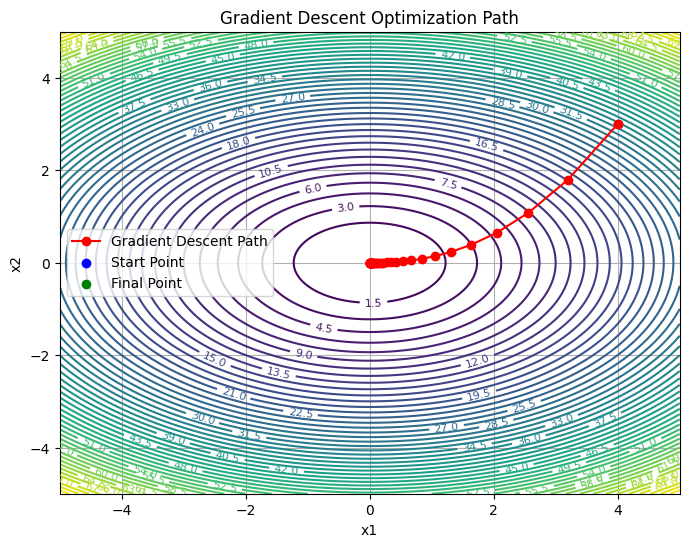

In [ ]:
#2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define the Objective Function
def objective_function(x):
    x1, x2 = x
    return x1**2 + 2 * x2**2

# Step 2: Compute the Gradient (Partial Derivatives)
def gradient(x):
    x1, x2 = x
    df_dx1 = 2 * x1
    df_dx2 = 4 * x2
    return np.array([df_dx1, df_dx2])

# Step 3: Implement Gradient Descent Algorithm
def gradient_descent(starting_point, learning_rate, iterations):
    x = np.array(starting_point, dtype='float64')
    path = [x.copy()]
    for _ in range(iterations):
        grad = gradient(x)
        x -= learning_rate * grad
        path.append(x.copy())
    return x, path

# Initialize parameters
alpha = 0.1
n_iterations = 50
initial_x = [4.0, 3.0]

# Run gradient descent
final_x, path = gradient_descent(initial_x, alpha, n_iterations)

# Step 4: Print final results
print("Final values:")
print(f"x1 = {final_x[0]:.4f}, x2 = {final_x[1]:.4f}")
print(f"f(x1, x2) = {objective_function(final_x):.4f}")

# Step 5: Visualize the Optimization Path
path = np.array(path)

# Create contour plot
x1_vals = np.linspace(-5, 5, 400)
x2_vals = np.linspace(-5, 5, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = X1**2 + 2*X2**2

plt.figure(figsize=(8, 6))
cp = plt.contour(X1, X2, Z, levels=50, cmap='viridis')
plt.clabel(cp, inline=True, fontsize=8)
plt.plot(path[:, 0], path[:, 1], 'ro-', label='Gradient Descent Path')
plt.scatter(initial_x[0], initial_x[1], color='blue', label='Start Point')
plt.scatter(final_x[0], final_x[1], color='green', label='Final Point')
plt.title("Gradient Descent Optimization Path")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


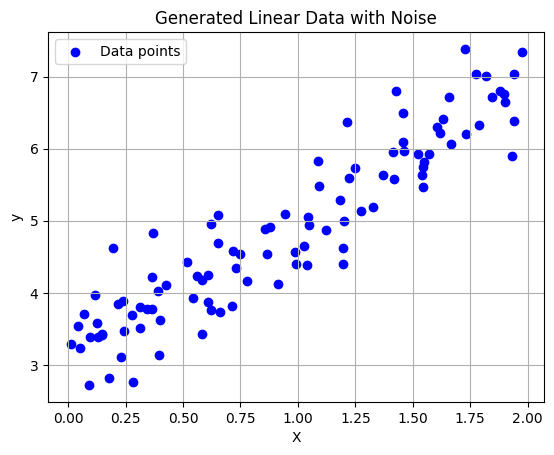

Final Parameters (theta):
[[2.95918912]
 [2.01604959]]


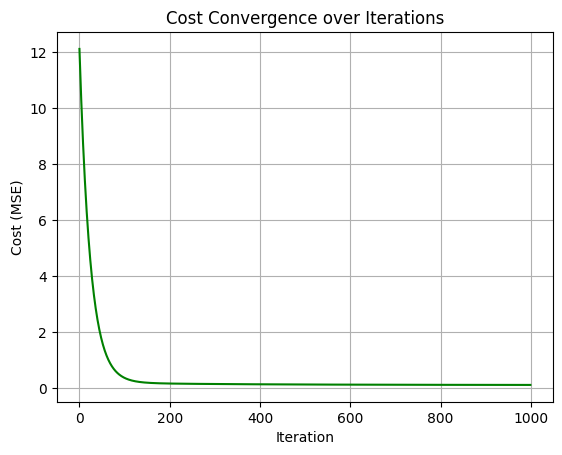

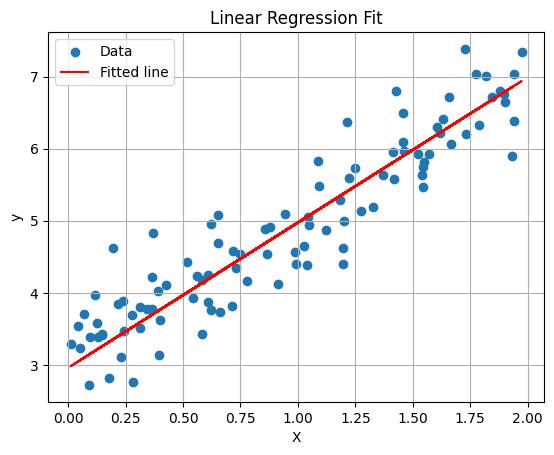

In [ ]:
#3
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)  # For reproducibility

n_samples = 100
X = 2 * np.random.rand(n_samples, 1)  # Features between 0 and 2
theta_true = np.array([[3], [2]])     # True parameters: y = 3 + 2x
noise = np.random.randn(n_samples, 1) * 0.5
X_b = np.c_[np.ones((n_samples, 1)), X]  # Add bias term (x0 = 1)

y = X_b.dot(theta_true) + noise

# 2. Visualize the data
plt.scatter(X, y, color='blue', label='Data points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Linear Data with Noise')
plt.legend()
plt.grid(True)
plt.show()

# 3. Define the Hypothesis Function
def hypothesis(X, theta):
    return X.dot(theta)

# 4. Define the Cost Function (MSE)
def compute_cost(X, y, theta):
    m = len(y)
    predictions = hypothesis(X, theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# 5. Compute Gradient
def compute_gradient(X, y, theta):
    m = len(y)
    return (1 / m) * X.T.dot(hypothesis(X, theta) - y)

# 6. Perform Gradient Descent
def gradient_descent(X, y, theta, alpha, n_iterations):
    cost_history = []
    for i in range(n_iterations):
        gradients = compute_gradient(X, y, theta)
        theta = theta - alpha * gradients
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
    return theta, cost_history

# Initialize parameters
theta_init = np.zeros((2, 1))
alpha = 0.01
iterations = 1000

# Train model
theta_final, cost_history = gradient_descent(X_b, y, theta_init, alpha, iterations)

# 7. Evaluate Model
print("Final Parameters (theta):")
print(theta_final)

# Plot cost history
plt.plot(range(iterations), cost_history, color='green')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Cost Convergence over Iterations')
plt.grid(True)
plt.show()

# Plot fitted line
plt.scatter(X, y, label='Data')
plt.plot(X, hypothesis(X_b, theta_final), color='red', label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()


Model Accuracy on Test Set: 0.9561

Actual vs Predicted (first 10 samples):
   Actual  Predicted
0       1          1
1       0          0
2       0          0
3       1          1
4       1          1
5       0          0
6       0          0
7       0          0
8       1          0
9       1          1


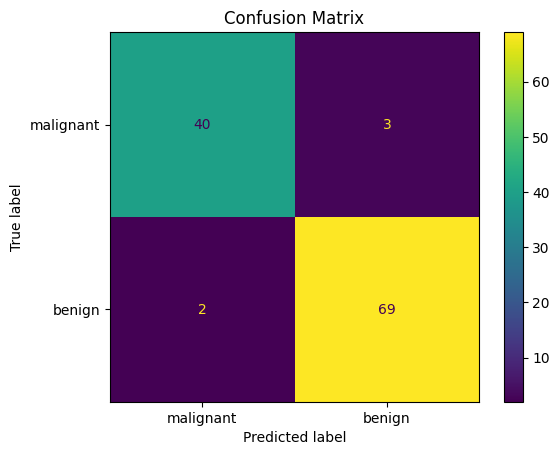

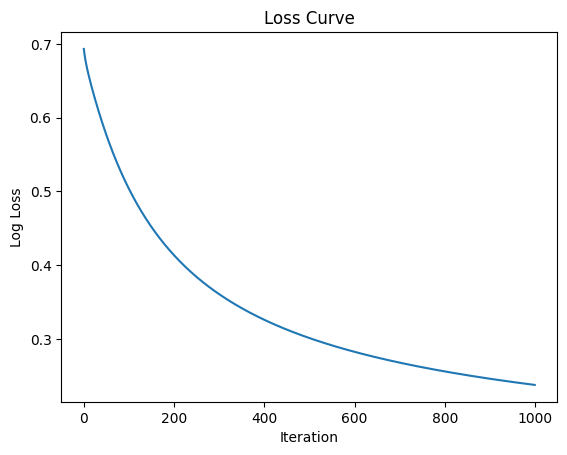

In [ ]:
#4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Step 2: Load and prepare dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features (optional but recommended)
X_train = X_train / np.max(X_train, axis=0)
X_test = X_test / np.max(X_test, axis=0)

# Step 3: Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Step 4: Logistic Regression Class
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            predictions = sigmoid(linear_model)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
            db = (1 / n_samples) * np.sum(predictions - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute loss (log loss)
            loss = -np.mean(y * np.log(predictions + 1e-15) + (1 - y) * np.log(1 - predictions + 1e-15))
            self.losses.append(loss)

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return sigmoid(linear_model)

    def predict(self, X):
        proba = self.predict_proba(X)
        return [1 if p >= 0.5 else 0 for p in proba]

# Step 5: Train the model
model = LogisticRegressionGD(learning_rate=0.1, iterations=1000)
model.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")

# Show first few actual vs predicted results
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nActual vs Predicted (first 10 samples):")
print(results_df.head(10))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Step 8: Plot loss curve over iterations
plt.plot(range(len(model.losses)), model.losses)
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Loss Curve")
plt.show()


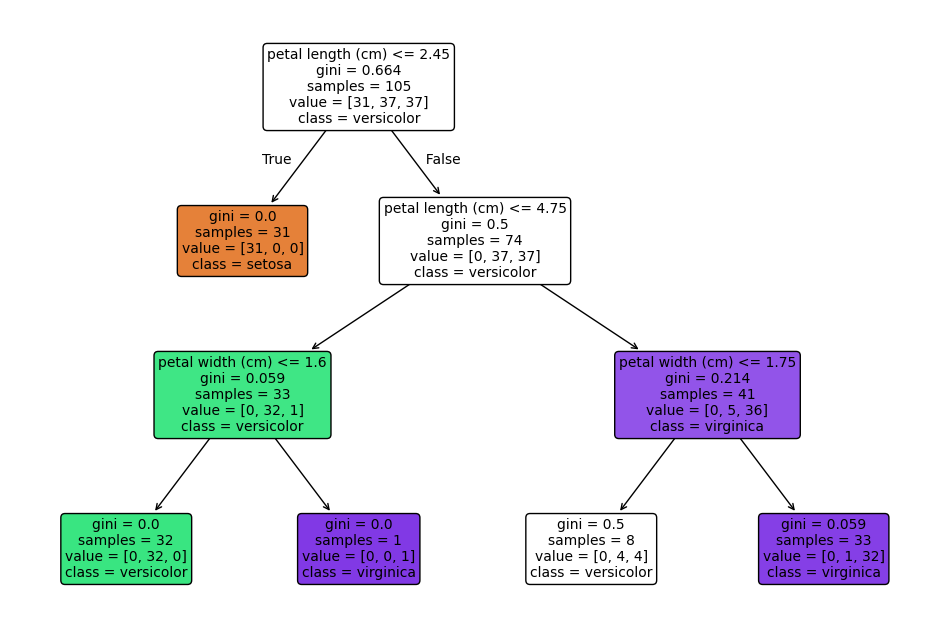


Accuracy: 0.96


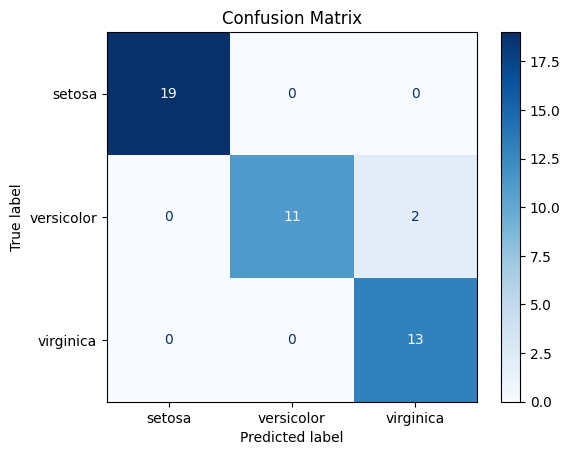

In [ ]:
#5
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier as SklearnTree
from sklearn.tree import plot_tree
import sklearn
# --- Decision Tree Node and Classifier ---
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.root = None
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    def predict(self, X):
        return [self._traverse_tree(x, self.root) for x in X]

    def _build_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        if (depth >= self.max_depth or num_labels == 1 or num_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        best_feat, best_thresh = self._best_split(X, y, num_features)

        if best_feat is None:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        indices_left = X[:, best_feat] <= best_thresh
        X_left, y_left = X[indices_left], y[indices_left]
        X_right, y_right = X[~indices_left], y[~indices_left]

        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        return Node(best_feat, best_thresh, left_child, right_child)

    def _best_split(self, X, y, num_features):
        best_gini = 1.0
        best_feat, best_thresh = None, None

        for feature_index in range(num_features):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                left_indices = X[:, feature_index] <= threshold
                right_indices = ~left_indices

                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue

                gini = self._gini_index(y[left_indices], y[right_indices])

                if gini < best_gini:
                    best_gini = gini
                    best_feat = feature_index
                    best_thresh = threshold

        return best_feat, best_thresh

    def _gini_index(self, left_labels, right_labels):
        def gini(labels):
            classes, counts = np.unique(labels, return_counts=True)
            probs = counts / counts.sum()
            return 1 - np.sum(probs ** 2)

        n = len(left_labels) + len(right_labels)
        gini_left = gini(left_labels)
        gini_right = gini(right_labels)

        return (len(left_labels) / n) * gini_left + (len(right_labels) / n) * gini_right

    def _most_common_label(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

    # Function to print the decision tree
    def print_tree(self, node=None, depth=0, feature_names=None):
        if node is None:
            node = self.root

        indent = "  " * depth
        if node.value is not None:
            print(f"{indent}Leaf: Class = {node.value}")
        else:
            feat_name = f"X[{node.feature_index}]" if not feature_names else feature_names[node.feature_index]
            print(f"{indent}Node: If {feat_name} <= {node.threshold:.2f}")
            self.print_tree(node.left, depth + 1, feature_names)
            print(f"{indent}else:")
            self.print_tree(node.right, depth + 1, feature_names)


# --- Load Data & Run ---
# Load data
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train custom tree
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

# Train sklearn tree
clf = SklearnTree(max_depth=3)
clf.fit(X_train, y_train)

# Plot
plt.figure(figsize=(12, 8))
plot_tree(clf,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

# Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Print the custom tree (optional)
# model.print_tree(feature_names=feature_names)


Training with kernel = linear, C = 1.0, gamma = scale
Accuracy: 0.8
Precision: 0.805
Recall: 0.8
F1 Score: 0.7973013493253375

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45



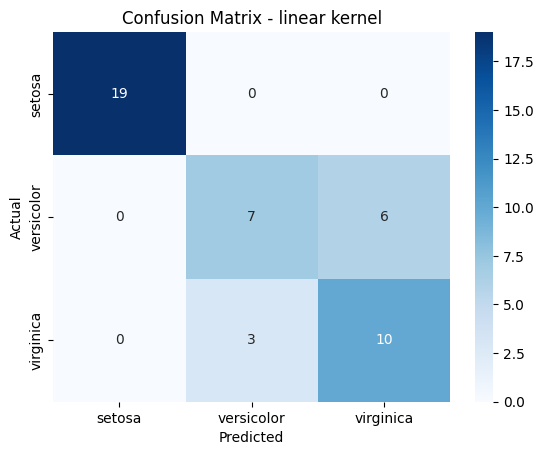

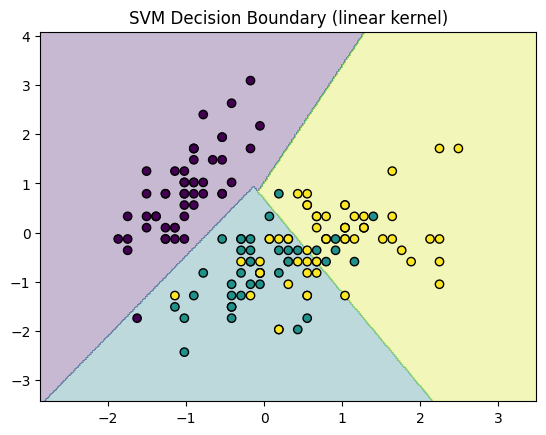


Training with kernel = rbf, C = 1.0, gamma = 0.7
Accuracy: 0.7777777777777778
Precision: 0.7793939393939393
Recall: 0.7777777777777778
F1 Score: 0.7764550264550264

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.64      0.54      0.58        13
           2       0.60      0.69      0.64        13

    accuracy                           0.78        45
   macro avg       0.75      0.74      0.74        45
weighted avg       0.78      0.78      0.78        45



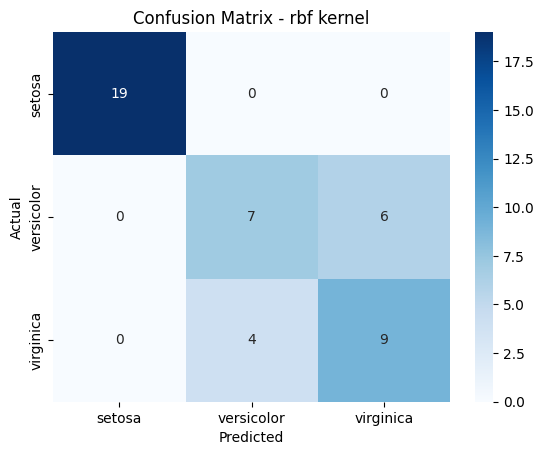

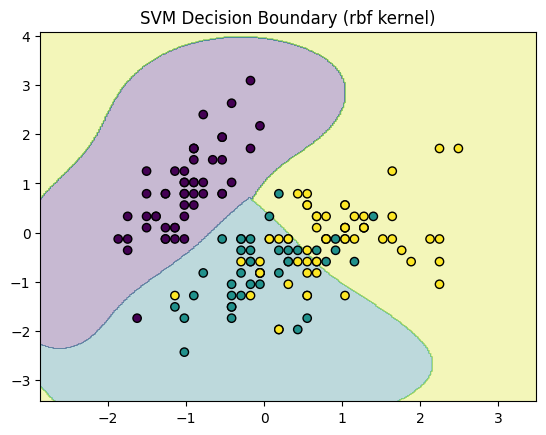


Training with kernel = poly, C = 1.0, gamma = scale
Accuracy: 0.7555555555555555
Precision: 0.8675925925925926
Recall: 0.7555555555555555
F1 Score: 0.7377161475200691

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94        19
           1       0.54      1.00      0.70        13
           2       1.00      0.31      0.47        13

    accuracy                           0.76        45
   macro avg       0.85      0.73      0.71        45
weighted avg       0.87      0.76      0.74        45



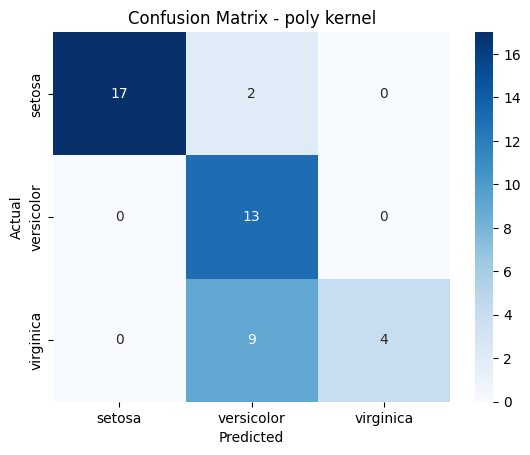

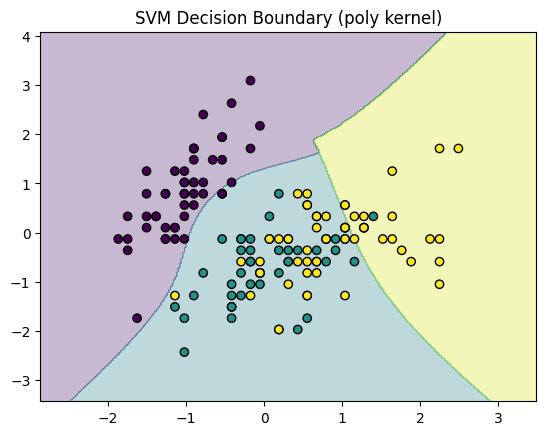

In [ ]:
#6
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Load Dataset (Using sklearn's built-in dataset: Iris for simplicity)
iris = datasets.load_iris()
X = iris.data[:, :2] # Taking only first 2 features for easy visualization
y = iris.target

# 2. Preprocess Data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Function to train and evaluate SVM
def train_evaluate_svm(kernel_type="linear", C=1.0, gamma="scale"):
  print(f"\nTraining with kernel = {kernel_type}, C = {C}, gamma = {gamma}")
  svm = SVC(kernel=kernel_type, C=C, gamma=gamma)
  svm.fit(X_train, y_train)

  # Predictions
  y_pred = svm.predict(X_test)

  # Evaluation
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print("Precision:", precision_score(y_test, y_pred, average='weighted'))
  print("Recall:", recall_score(y_test, y_pred, average='weighted'))
  print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
  print("\nClassification Report:\n", classification_report(y_test, y_pred))

  # Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
  plt.title(f"Confusion Matrix - {kernel_type} kernel")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

  # Decision boundary visualization (only works with 2 features)
  h = .02 # step size
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
  np.arange(y_min, y_max, h))

  Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
  plt.title(f"SVM Decision Boundary ({kernel_type} kernel)")
  plt.show()

# 3. Experiment with different kernels
train_evaluate_svm(kernel_type="linear", C=1.0)
train_evaluate_svm(kernel_type="rbf", C=1.0, gamma=0.7)
train_evaluate_svm(kernel_type="poly", C=1.0, gamma="scale")



=== Bagging (Random Forest) ===
Accuracy: 0.9707602339181286
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



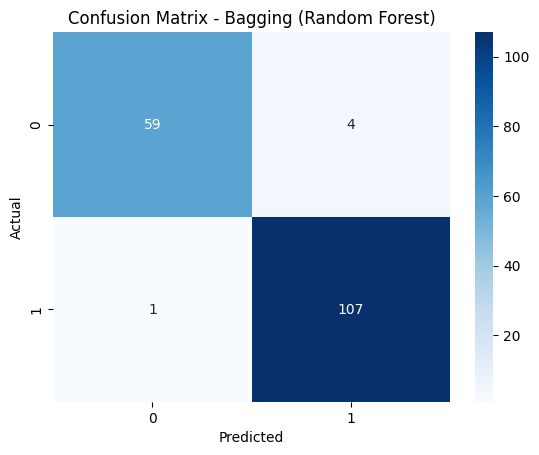


=== Boosting (AdaBoost) ===
Accuracy: 0.9590643274853801
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.94        63
           1       0.95      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



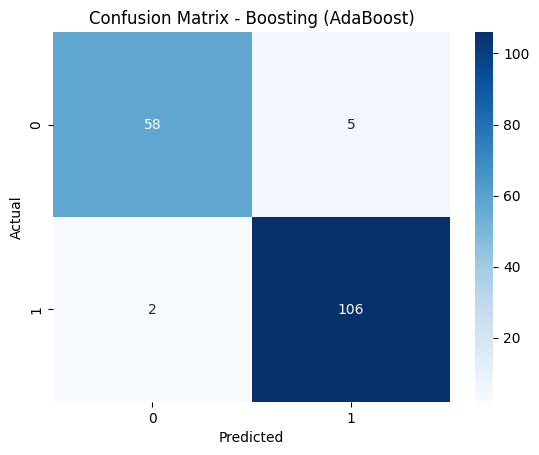


=== Stacking ===
Accuracy: 0.9766081871345029
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



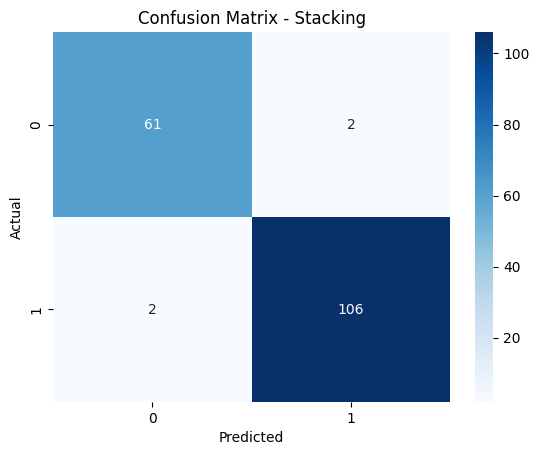

In [ ]:
#7 Ensemble Methods: Bagging, Boosting, Stacking

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# 1. Load Dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Preprocess
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Bagging (Random Forest)
bagging_model = RandomForestClassifier(n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)

# 3. Boosting (AdaBoost)
boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
boosting_model.fit(X_train, y_train)
y_pred_boost = boosting_model.predict(X_test)

# 4. Stacking
base_learners = [
    ('dt', DecisionTreeClassifier(max_depth=3)),
    ('svm', SVC(probability=True, kernel='rbf')),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
]
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

# 5. Evaluate Models
def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate_model("Bagging (Random Forest)", y_test, y_pred_bag)
evaluate_model("Boosting (AdaBoost)", y_test, y_pred_boost)
evaluate_model("Stacking", y_test, y_pred_stack)

Dataset shape: (150, 4)
Explained variance ratio: [0.7184292  0.24178316]
Accuracy: 0.9111111111111111
Precision: 0.9155354449472096
Recall: 0.9111111111111111
F1 Score: 0.9107142857142857


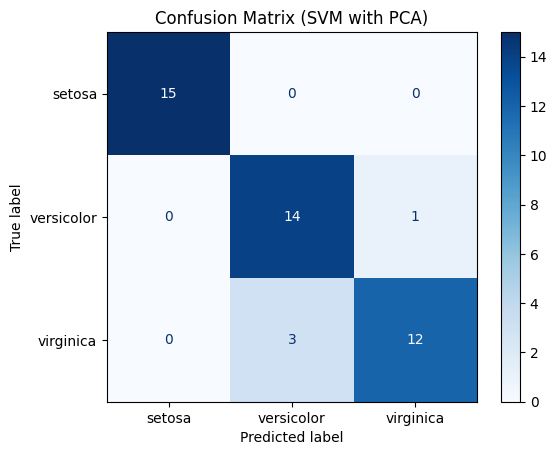

Accuracy without PCA: 0.9111111111111111


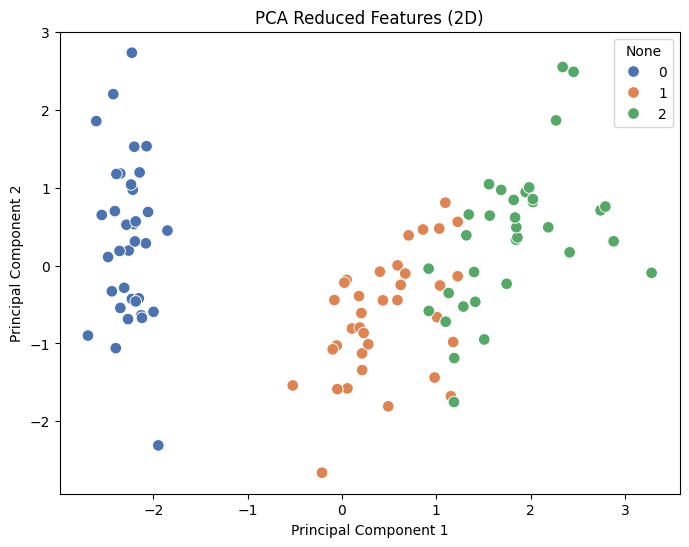

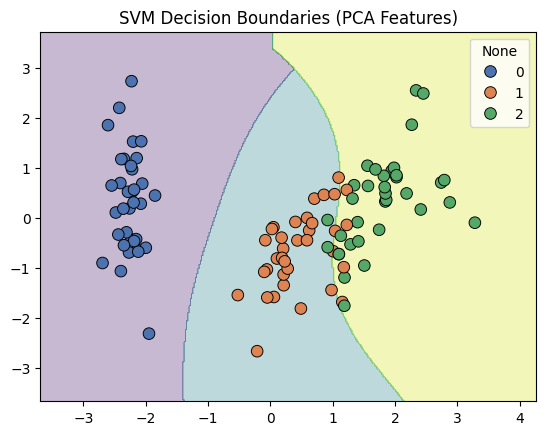


--- Summary ---
Accuracy with PCA: 0.9111111111111111
Accuracy without PCA: 0.9111111111111111
Trade-off: PCA reduces dimensions (faster computation, easier visualization) but may lose some variance.


In [ ]:
#8
# 1. Setup Environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 2. Load Dataset (example: Iris dataset)
from sklearn.datasets import load_iris
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)

# 3. Preprocess Data
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 4. Apply PCA
pca = PCA(n_components=2)  # keep 2 components for visualization
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# 5. Initialize SVM Classifier
svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

# 6. Train the Model
svm.fit(X_train_pca, y_train)

# 7. Make Predictions
y_pred = svm.predict(X_test_pca)

# 8. Evaluate Model Performance
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (SVM with PCA)")
plt.show()

# Compare with SVM without PCA
svm_no_pca = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_no_pca.fit(X_train, y_train)
y_pred_no_pca = svm_no_pca.predict(X_test)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Accuracy without PCA:", acc_no_pca)

# 9. Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_train_pca[:,0], y=X_train_pca[:,1], hue=y_train, palette="deep", s=70)
plt.title("PCA Reduced Features (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Decision boundary visualization
h = .02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_train_pca[:,0], y=X_train_pca[:,1], hue=y_train, palette="deep", s=70, edgecolor="k")
plt.title("SVM Decision Boundaries (PCA Features)")
plt.show()

# 10. Summarize Results
print("\n--- Summary ---")
print("Accuracy with PCA:", acc)
print("Accuracy without PCA:", acc_no_pca)
print("Trade-off: PCA reduces dimensions (faster computation, easier visualization) but may lose some variance.")
